# DATA2901 - Practical Assignment: Greater Sydney Analysis
by Michelangelo Nardi (540602704), Scott Barton (530584285), Janet Li (311279139)

## Task 1

### 1.1 Import packages

In [1]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install geopandas
# !pip install geoalchemy2
# !pip install sqlalchemy

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import os
import glob

import requests
from bs4 import BeautifulSoup
import html5lib

from sqlalchemy import create_engine
import psycopg2
import psycopg2.extras
import json

import shapely
import seaborn as sns

from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')
from sklearn import linear_model
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split

### 1.2 Connect to SQL server 

In [2]:
# !pip install psycopg2
# !pip install psycopg2-binary --user
# !pip install psycopg[binary]

credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

In [3]:
db, conn = pgconnect(credentials)

Connected successfully.


In [4]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


### 1.3 Import datasets
All files are in one folder called "Data"

#### Csv files (4)

In [5]:
# get all the files in csv
path = os.getcwd() 
csv_files = glob.glob(os.path.join(path, "Data/*.csv")) 

print(csv_files)

# create empty list
dataframes_list = []
 
# append datasets into the list
for i in csv_files:
    temp_df = pd.read_csv(i)
    dataframes_list.append(temp_df)

df_income = dataframes_list[1]
df_pop = dataframes_list[3]
df_pol = dataframes_list[2]
df_business = dataframes_list[0]
print("Income: ",df_income.shape,'; ',df_income.columns)
print('Population: ',df_pop.shape,'; ',df_pop.columns)
print('Polling: ',df_pol.shape,'; ',df_pol.columns)
print('Business: ',df_business.shape,'; ',df_business.columns)

['c:\\Users\\nardi\\Desktop\\Università\\Bocconi\\3 anno\\Semestre 3.2 (Sydney)\\Big Data and Data Diversity\\Assignment\\Mike changes\\Data\\Businesses.csv', 'c:\\Users\\nardi\\Desktop\\Università\\Bocconi\\3 anno\\Semestre 3.2 (Sydney)\\Big Data and Data Diversity\\Assignment\\Mike changes\\Data\\Income.csv', 'c:\\Users\\nardi\\Desktop\\Università\\Bocconi\\3 anno\\Semestre 3.2 (Sydney)\\Big Data and Data Diversity\\Assignment\\Mike changes\\Data\\PollingPlaces2019.csv', 'c:\\Users\\nardi\\Desktop\\Università\\Bocconi\\3 anno\\Semestre 3.2 (Sydney)\\Big Data and Data Diversity\\Assignment\\Mike changes\\Data\\Population.csv']
Income:  (642, 6) ;  Index(['sa2_code21', 'sa2_name', 'earners', 'median_age', 'median_income',
       'mean_income'],
      dtype='object')
Population:  (373, 21) ;  Index(['sa2_code', 'sa2_name', '0-4_people', '5-9_people', '10-14_people',
       '15-19_people', '20-24_people', '25-29_people', '30-34_people',
       '35-39_people', '40-44_people', '45-49_peopl

In [6]:
df_income.head()

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640,68904
1,101021008,Karabar,5103,42,65564,69672
2,101021009,Queanbeyan,7028,39,63528,69174
3,101021010,Queanbeyan - East,3398,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630,91981


In [7]:
df_pop.head()

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346


In [8]:
df_pol.head()

,FID,state,division_id,division_name,polling_place_id,polling_place_type_id,polling_place_name,premises_name,premises_address_1,premises_address_2,premises_address_3,premises_suburb,premises_state_abbreviation,premises_post_code,latitude,longitude,the_geom
0,aec_federal_election_polling_places_2019.fid-4...,NSW,104,Barton,33595,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
1,aec_federal_election_polling_places_2019.fid-4...,NSW,105,Bennelong,33596,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
2,aec_federal_election_polling_places_2019.fid-4...,NSW,107,Blaxland,33600,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
3,aec_federal_election_polling_places_2019.fid-4...,NSW,109,Calare,33603,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,ORANGE,NSW,2800.0,NaN,NaN,NaN
4,aec_federal_election_polling_places_2019.fid-4...,NSW,113,Cowper,33716,2,Special Hospital Team 2,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN


In [9]:
df_business.head()

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16


#### Txt file (1)

In [10]:
# import txt file
# path = os.getcwd() 
txt_files = glob.glob(os.path.join(path, "*/*.txt")) 
print(txt_files[0])
i = txt_files[0]
df_stops = pd.read_csv(i)
print(df_stops.shape)
print(df_stops.columns)
df_stops.tail()

c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes\Data\Stops.txt
(114718, 9)
Index(['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon',
       'location_type', 'parent_station', 'wheelchair_boarding',
       'platform_code'],
      dtype='object')


,stop_id,stop_code,stop_name,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code
114713,212753,212753.0,"Sydney Olympic Park Wharf, Side B",-33.822016,151.078797,NaN,21271,1,B
114714,2137185,2137185.0,"Cabarita Wharf, Side A",-33.840669,151.116926,NaN,21371,1,1A
114715,2137186,2137186.0,"Cabarita Wharf, Side B",-33.840769,151.116899,NaN,21371,1,1B
114716,21501,21501.0,Parramatta Wharf,-33.813904,151.010577,NaN,2150112,1,NaN
114717,2150112,NaN,Parramatta Wharf,-33.813952,151.010482,1.0,NaN,1,NaN


#### Shp files (2)

In [11]:
# get the shp files
print(path)
shp_files = glob.glob(os.path.join(path, "Data/*/*.shp")) 

# create empty list
dataframes_list_shp = []
 
# append datasets into the list
for i in shp_files:
    print(i)
    temp_df = gpd.read_file(i, crs="EPSG:4326")
    dataframes_list_shp.append(temp_df)

df_catch_f = dataframes_list_shp[0]
df_catch_s = dataframes_list_shp[2]
df_catch_p = dataframes_list_shp[1]
df_sa2 = dataframes_list_shp[3]
print("catchment future: ",df_catch_f.shape,'; ',df_catch_f.columns)
print('catchment secondary: ',df_catch_s.shape,'; ',df_catch_s.columns)
print('catchment primary: ',df_catch_p.shape,'; ',df_catch_p.columns)
print('sa2: ',df_sa2.shape,'; ',df_sa2.columns)

c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes
c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes\Data\catchments\catchments_future.shp
c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes\Data\catchments\catchments_primary.shp
c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes\Data\catchments\catchments_secondary.shp
c:\Users\nardi\Desktop\Università\Bocconi\3 anno\Semestre 3.2 (Sydney)\Big Data and Data Diversity\Assignment\Mike changes\Data\SA2_2021_AUST_SHP_GDA2020\SA2_2021_AUST_GDA2020.shp
catchment future:  (30, 18) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR

In [12]:
df_catch_f.head()

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,geometry
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.19849 -33.53990, 151.19945 -33.5..."
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.27152 -33.91402, 151.27152 -33.9..."
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,"POLYGON ((151.15292 -33.83939, 151.16144 -33.8..."
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.17794 -33.69820, 151.17859 -33.6..."
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.28072 -33.83287, 151.28095 -33.8..."


In [13]:
df_catch_p.head()

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
0,2838,PRIMARY,Parklea PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((150.93564 -33.71612, 150.93715 -33.7..."
1,2404,PRIMARY,Lindfield EPS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.18336 -33.74748, 151.18443 -33.7..."
2,4393,PRIMARY,Carlingford WPS,20220223,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.04518 -33.77303, 151.04526 -33.7..."
3,4615,PRIMARY,Caddies Ck PS,20181210,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((150.92567 -33.72960, 150.92602 -33.7..."
4,3918,PRIMARY,Killara PS,20211219,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((151.15379 -33.75586, 151.15404 -33.7..."


In [14]:
df_catch_s.head()

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.67182 -35.31444, 146.68930 -35.3..."
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((147.08734 -35.86271, 147.10413 -35.8..."
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.81448 -35.78341, 146.81250 -35.7..."
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"MULTIPOLYGON (((150.68600 -33.74031, 150.68631..."
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((150.69513 -33.75627, 150.68936 -33.7..."


In [15]:
df_sa2.head()

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.21800 -35.3..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.19970 -35.3..."


In [16]:
df_sa2.dtypes

SA2_CODE21      object
SA2_NAME21      object
CHG_FLAG21      object
CHG_LBL21       object
SA3_CODE21      object
SA3_NAME21      object
SA4_CODE21      object
SA4_NAME21      object
GCC_CODE21      object
GCC_NAME21      object
STE_CODE21      object
STE_NAME21      object
AUS_CODE21      object
AUS_NAME21      object
AREASQKM21     float64
LOCI_URI21      object
geometry      geometry
dtype: object

### 1.4 Checks and cleaning

In [17]:
# Concatenate all the school datasets

# Add column 'PRIORITY' to secondary school df
df_catch_s['PRIORITY'] = 'None'
df_catch_s1 = df_catch_s[['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry']]

#Concatenate
df_school = pd.concat([df_catch_f, df_catch_s1,df_catch_p])
print(df_school.shape)
df_school.tail()

(2128, 19)


,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,geometry,PRIORITY
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((147.94621 -34.55863, 147.95292 -34.5...",None
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((148.12885 -35.60082, 148.23155 -35.6...",None
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((146.86148 -35.87511, 146.87402 -35.8...",None
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((145.18403 -29.65805, 145.18434 -29.6...",None
1661,2155,PRIMARY,Hermidale PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((146.46001 -31.31688, 146.47453 -31.3...",None


In [18]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

df_schoolog = df_school.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_school['geom'] = df_school['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_school = df_school.drop(columns="geometry")  # deleting the old copy
df_school

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geom
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.19848917708944 -33.5398987...
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.27151530428182 -33.9140183...
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,NaN,MULTIPOLYGON (((151.15292370935092 -33.8393921...
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.17793729938725 -33.6982001...
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.28072275958445 -33.8328728...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((147.9462089946497 -34.55863148...
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((148.12885348977485 -35.6008184...
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((146.86147943204122 -35.8751106...
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((145.18402754685187 -29.6580498...


In [19]:
# We confirm that there are no duplicate rows
print(df_school.shape)
print(df_school.drop_duplicates().shape)

print(df_business.shape)
print(df_business.drop_duplicates().shape)

print(df_income.shape)
print(df_income.drop_duplicates().shape)

print(df_pol.shape)
print(df_pol.drop_duplicates().shape)

print(df_pop.shape)
print(df_pop.drop_duplicates().shape)

print(df_stops.shape)
print(df_stops.drop_duplicates().shape)



(2128, 19)
(2128, 19)
(12217, 11)
(12217, 11)
(642, 6)
(642, 6)
(2930, 17)
(2930, 17)
(373, 21)
(373, 21)
(114718, 9)
(114718, 9)


In [20]:
print(df_school.dtypes)
print(df_school.isna().sum())
df_school.nunique()

USE_ID        object
CATCH_TYPE    object
USE_DESC      object
ADD_DATE      object
KINDERGART    object
YEAR1         object
YEAR2         object
YEAR3         object
YEAR4         object
YEAR5         object
YEAR6         object
YEAR7         object
YEAR8         object
YEAR9         object
YEAR10        object
YEAR11        object
YEAR12        object
PRIORITY      object
geom          object
dtype: object
USE_ID           0
CATCH_TYPE       0
USE_DESC         0
ADD_DATE       391
KINDERGART       0
YEAR1            0
YEAR2            0
YEAR3            0
YEAR4            0
YEAR5            0
YEAR6            0
YEAR7            0
YEAR8            0
YEAR9            0
YEAR10           0
YEAR11           0
YEAR12           0
PRIORITY      1688
geom             0
dtype: int64


USE_ID        2035
CATCH_TYPE       7
USE_DESC      2035
ADD_DATE       209
KINDERGART       4
YEAR1            4
YEAR2            4
YEAR3            4
YEAR4            4
YEAR5            4
YEAR6            4
YEAR7            4
YEAR8            4
YEAR9            4
YEAR10           5
YEAR11           5
YEAR12           6
PRIORITY         2
geom          2084
dtype: int64

In [21]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [22]:
print(df_pol.dtypes)
print(df_pol.isna().sum())
df_pol.nunique()

FID                             object
state                           object
division_id                      int64
division_name                   object
polling_place_id                 int64
polling_place_type_id            int64
polling_place_name              object
premises_name                   object
premises_address_1              object
premises_address_2              object
premises_address_3              object
premises_suburb                 object
premises_state_abbreviation     object
premises_post_code             float64
latitude                       float64
longitude                      float64
the_geom                        object
dtype: object
FID                               0
state                             0
division_id                       0
division_name                     0
polling_place_id                  0
polling_place_type_id             0
polling_place_name                0
premises_name                     0
premises_address_1              193

FID                            2930
state                             1
division_id                      47
division_name                    47
polling_place_id               2930
polling_place_type_id             4
polling_place_name             2757
premises_name                  2463
premises_address_1             2408
premises_address_2               46
premises_address_3                7
premises_suburb                1522
premises_state_abbreviation       3
premises_post_code              593
latitude                       2498
longitude                      2242
the_geom                       2543
dtype: int64

In [23]:
print(df_pop.dtypes)
print(df_pop.isna().sum())
df_pop.nunique()

sa2_code               int64
sa2_name              object
0-4_people             int64
5-9_people             int64
10-14_people           int64
15-19_people           int64
20-24_people           int64
25-29_people           int64
30-34_people           int64
35-39_people           int64
40-44_people           int64
45-49_people           int64
50-54_people           int64
55-59_people           int64
60-64_people           int64
65-69_people           int64
70-74_people           int64
75-79_people           int64
80-84_people           int64
85-and-over_people     int64
total_people           int64
dtype: object
sa2_code              0
sa2_name              0
0-4_people            0
5-9_people            0
10-14_people          0
15-19_people          0
20-24_people          0
25-29_people          0
30-34_people          0
35-39_people          0
40-44_people          0
45-49_people          0
50-54_people          0
55-59_people          0
60-64_people          0
65-69_people     

sa2_code              373
sa2_name              373
0-4_people            324
5-9_people            327
10-14_people          332
15-19_people          318
20-24_people          324
25-29_people          340
30-34_people          336
35-39_people          331
40-44_people          328
45-49_people          326
50-54_people          326
55-59_people          317
60-64_people          314
65-69_people          304
70-74_people          302
75-79_people          286
80-84_people          258
85-and-over_people    272
total_people          365
dtype: int64

In [24]:
print(df_stops.dtypes)
print(df_stops.isna().sum())
df_stops.nunique()

stop_id                 object
stop_code              float64
stop_name               object
stop_lat               float64
stop_lon               float64
location_type          float64
parent_station          object
wheelchair_boarding      int64
platform_code           object
dtype: object
stop_id                     0
stop_code               53999
stop_name                   0
stop_lat                    0
stop_lon                    0
location_type           60727
parent_station          53991
wheelchair_boarding         0
platform_code          113847
dtype: int64


stop_id                114718
stop_code               60719
stop_name               62577
stop_lat                78935
stop_lon                78935
location_type               1
parent_station          53991
wheelchair_boarding         3
platform_code              36
dtype: int64

In [25]:
print(df_income.dtypes)
print(df_income.isna().sum())
df_income.nunique()

sa2_code21        int64
sa2_name         object
earners          object
median_age       object
median_income    object
mean_income      object
dtype: object
sa2_code21       0
sa2_name         0
earners          0
median_age       0
median_income    0
mean_income      0
dtype: int64


sa2_code21       642
sa2_name         642
earners          623
median_age        29
median_income    635
mean_income      631
dtype: int64

In [26]:
df_sa2['geometry'] != None

0        True
1        True
2        True
3        True
4        True
        ...  
2468     True
2469     True
2470    False
2471    False
2472    False
Name: geometry, Length: 2473, dtype: bool

In [27]:
df_sa2['geometry'].geom_type == 'Polygon'
df_sa2.dtypes

SA2_CODE21      object
SA2_NAME21      object
CHG_FLAG21      object
CHG_LBL21       object
SA3_CODE21      object
SA3_NAME21      object
SA4_CODE21      object
SA4_NAME21      object
GCC_CODE21      object
GCC_NAME21      object
STE_CODE21      object
STE_NAME21      object
AUS_CODE21      object
AUS_NAME21      object
AREASQKM21     float64
LOCI_URI21      object
geometry      geometry
dtype: object

In [28]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

df_sa2og = df_sa2.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_sa2 = df_sa2[df_sa2['geometry'] != None] # remove rows without any geometry data
df_sa2['geom'] = df_sa2['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_sa2 = df_sa2.drop(columns="geometry")  # deleting the old copy
df_sa2

c:\Users\nardi\Anaconda3\lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geom
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.58423846300806 -35.4442571...
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2189874391411 -35.36738117...
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.21326493309647 -35.3432452...
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.2403376383506 -35.34780977...
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((149.19572324350193 -35.3612624...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463,801111141,Namadgi,0,No change,80111,Uriarra - Namadgi,801,Australian Capital Territory,8ACTE,Australian Capital Territory,8,Australian Capital Territory,AUS,Australia,1202.7527,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((148.8040699920124 -35.37619101...
2466,901011001,Christmas Island,0,No change,90101,Christmas Island,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,136.1356,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((105.67392869067984 -10.4156603...
2467,901021002,Cocos (Keeling) Islands,0,No change,90102,Cocos (Keeling) Islands,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,13.7258,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((96.91512206484654 -12.14044140...
2468,901031003,Jervis Bay,0,No change,90103,Jervis Bay,901,Other Territories,9OTER,Other Territories,9,Other Territories,AUS,Australia,67.2296,http://linked.data.gov.au/dataset/asgsed3/SA2/...,MULTIPOLYGON (((150.6956683280878 -35.18295428...


In [29]:
# keep columns only when valid data exists -- drop 7 columns due to no valid value in earners and median age/income
# Change column values to integers
df_income = df_income[df_income.earners != 'np'].astype({'earners': int, 'median_age': int,'median_income': int,'mean_income': int})
print(df_income.dtypes)

sa2_code21        int64
sa2_name         object
earners           int32
median_age        int32
median_income     int32
mean_income       int32
dtype: object


### 1.5 Import into SQL server

In [30]:
conn.execute("""
DROP TABLE IF EXISTS polls;
CREATE TABLE polls (
    FID                             varchar(100),
state                           varchar(100),
division_id                      integer primary key,
division_name                   varchar(100),
polling_place_id                 integer,
polling_place_type_id            integer,
polling_place_name              varchar(100),
premises_name                   varchar(100),
premises_address_1              varchar(100),
premises_address_2              varchar(100),
premises_address_3              varchar(100),
premises_suburb                 varchar(100),
premises_state_abbreviation     varchar(100),
premises_post_code             integer,
latitude                       float,
longitude                      float,
the_geom                       GEOMETRY(POINT,4326)
);"""
)
df_pol.to_sql('polls', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from polls")

print("polls created")

conn.execute("""
DROP TABLE IF EXISTS populations;
CREATE TABLE populations (
    pop_est NUMERIC, 
    continent VARCHAR(80), 
    name VARCHAR(80), 
    iso_a3 VARCHAR(80), 
    gdp_md_est NUMERIC,
    geom GEOMETRY(MULTIPOLYGON,4326) primary key
);"""
)
df_pop.to_sql('populations', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from populations")

print("population created")

conn.execute("""
DROP TABLE IF EXISTS incomes;
CREATE TABLE incomes (
    sa2_code21        integer primary key,
sa2_name         varchar(100),
earners          integer,
median_age       integer,
median_income    integer,
mean_income      integer
);"""
)
df_income.to_sql('incomes', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from incomes")

print("incomes created")

conn.execute("""
DROP TABLE IF EXISTS schools;
CREATE TABLE schools (
USE_ID        integer,
CATCH_TYPE    varchar(100),
USE_DESC      varchar(100),
ADD_DATE      date,
KINDERGART    varchar(100),
YEAR1         varchar(100),
YEAR2         varchar(100),
YEAR3         varchar(100),
YEAR4         varchar(100),
YEAR5         varchar(100),
YEAR6         varchar(100),
YEAR7         varchar(100),
YEAR8         varchar(100),
YEAR9         varchar(100),
YEAR10        varchar(100),
YEAR11        varchar(100),
YEAR12        varchar(100),
PRIORITY      varchar(100),
    geom GEOMETRY(MULTIPOLYGON,4326) primary key
);"""
)
df_school.to_sql('schools', conn, if_exists='replace', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from schools")

print("schools created")

conn.execute("""
DROP TABLE IF EXISTS business;
CREATE TABLE business (
    industry_code             varchar(100),
    industry_name             varchar(100),
    sa2_code                   integer,
    sa2_name                  varchar(100),
    "0_to_50k_businesses"       integer,
    "50k_to_200k_businesses"     integer,
    "200k_to_2m_businesses"      integer,
    "2m_to_5m_businesses"        integer,
    "5m_to_10m_businesses"       integer,
    "10m_or_more_businesses"     integer,
    total_businesses           integer
);"""
)
df_business.to_sql('business', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from business")

print("business created")

conn.execute("""
DROP TABLE IF EXISTS stops;
CREATE TABLE stops (
stop_id int primary key, 
stop_code int, 
stop_name varchar(100), 
stop_lat float, 
stop_lon float,
location_type int, 
parent_station int, 
wheelchair_boarding int,
platform_code varchar(100)
);"""
)
df_stops.to_sql('stops', conn, if_exists='replace', index=False)
query(conn, "select * from stops")

print("stops created")

conn.execute("""
DROP TABLE IF EXISTS sa2;
CREATE TABLE sa2 (
SA2_CODE21      integer primary key,
SA2_NAME21      varchar(100),
CHG_FLAG21      varchar(100),
CHG_LBL21       varchar(100),
SA3_CODE21      integer,
SA3_NAME21      varchar(100),
SA4_CODE21      integer,
SA4_NAME21      varchar(100),
GCC_CODE21      varchar(100),
GCC_NAME21      varchar(100),
STE_CODE21      integer,
STE_NAME21      varchar(100),
AUS_CODE21      varchar(100),
AUS_NAME21      varchar(100),
AREASQKM21     float,
LOCI_URI21      varchar(100),
geometry      geometry(Multipolygon,4326)
             );"""
)
df_sa2.to_sql('sa2', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from sa2")

print("sa2 created")

polls created
population created
incomes created
schools created
business created
stops created
sa2 created


## Task 2

### 2.1 Merge into one big dataset

In [31]:
conn.execute('''
	drop table if exists combined;
    create table combined as
	with poll as (
	select
		*,
		ST_SetSRID(st_makepoint("longitude", "latitude"), 4326) as geom
	from
		polls
	where
		the_geom is not null
),
stop as (
	select
		*,
		ST_SetSRID(st_makepoint("stop_lon", "stop_lat"), 4326) as geom
	from
		stops
	where
		stop_lat is not null
		and stop_lon is not null
),
join_polls as (
	select
		s."SA2_CODE21",
		s."SA2_NAME21",
		s."SA3_NAME21",
		s."SA4_NAME21",
		"STE_NAME21",
		s."GCC_NAME21",
		s.geom,
		ST_Area(s.geom) * 1000000 as area_size,
		count(distinct p.*) as num_polls
	from
		sa2 s
		left join poll p on st_contains(s.geom, p.geom) -- 2505
	group by
		1,
		2,
		3,
		4,
		5,
		6,
		7,
		8
),
join_schools as (
	select
		s."SA2_CODE21",
		s."SA2_NAME21",
		s."SA3_NAME21",
		s."SA4_NAME21",
		"STE_NAME21",
		s."GCC_NAME21",
		s.geom,
		s.area_size,
		num_polls,
		count(distinct sch."USE_ID") as num_schools
	from
		join_polls s
		left join schools sch on st_intersects(s.geom, sch.geom)
	group by
		1,
		2,
		3,
		4,
		5,
		6,
		7,
		8,
		9
),
join_stops as (
	select
		s."SA2_CODE21",
		s."SA2_NAME21",
		s."SA3_NAME21",
		s."SA4_NAME21",
		"STE_NAME21",
		s."GCC_NAME21",
		s.geom,
		s.area_size,
		num_polls,
		num_schools,
		count(distinct stop_id) as num_stops
	from
		join_schools s
		left join stop on st_contains(s.geom, stop.geom)
	group by
		1,
		2,
		3,
		4,
		5,
		6,
		7,
		8,
		9,
		10
)
select
	s."SA2_CODE21",
	s."SA2_NAME21",
	s."SA3_NAME21",
	s."SA4_NAME21",
	"STE_NAME21",
	s."GCC_NAME21",
	s.geom,
	s.area_size,
	num_polls,
	num_schools,
	num_stops,
	sum(i.earners) as num_earners,
	avg(i.median_age) as median_age,
	avg(i.median_income) as median_income,
	avg(i.mean_income) as mean_income,
	sum(b.total_businesses) as total_businesses,
	sum(
		"0_to_50k_businesses" * 25 + "50k_to_200k_businesses" * 125 + "200k_to_2m_businesses" * 1100 + "2m_to_5m_businesses" * 3500 + "5m_to_10m_businesses" * 7500 + "10m_or_more_businesses" * 12000
	) as Total_turnover,
	sum(
		ppl."0-4_people" + ppl."5-9_people" + ppl."10-14_people" + ppl."15-19_people"
	) as num_0_19_people,
	case
		when sum("total_people") = 0 then null
		else sum(
			ppl."0-4_people" + ppl."5-9_people" + ppl."10-14_people" + ppl."15-19_people"
		) / sum(ppl."total_people")
	end as Young_perc,
	sum("total_people") total_people
from
	join_stops s
	left join business b on b.sa2_code = cast(s."SA2_CODE21" as int)
	and industry_name in (
		'Manufacturing',
		'Health Care and Social Assistance',
		'Arts and Recreation Services',
		'Accommodation and Food Services',
		'Education and Training',
		'Retail Trade'
	) -- inner 11229 -- select only bustling industry
	left join populations ppl on ppl.sa2_code = cast(s."SA2_CODE21" as int) -- inner 359
	left join incomes i on i."sa2_code21" = cast(s."SA2_CODE21" as int) --inner 591
where
	num_polls is not null
	or num_schools is not null
	or num_stops is not null
	or i.earners is not null
	or b.total_businesses is not null
	or ppl.total_people is not null
group by
	1,
	2,
	3,
	4,
	5,
	6,
	7,
	8,
	9,
	10,
	11
''')
df_combined = query(conn, "select * from combined")

In [ ]:
df_combined.head()

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,GCC_NAME21,geom,area_size,num_polls,num_schools,num_stops,num_earners,median_age,median_income,mean_income,total_businesses,total_turnover,num_0_19_people,young_perc,total_people
0,101021007,Braidwood,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E6100000010000000103000000010000005D...,339396.981825,3,16,427,14802.0,51.0,46640.0,68904.0,124.0,81350.0,NaN,NaN,NaN
1,101021008,Karabar,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E6100000010000000103000000010000002C...,692.573630,1,7,86,30618.0,42.0,65564.0,69672.0,73.0,34500.0,NaN,NaN,NaN
2,101021009,Queanbeyan,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E61000000100000001030000000100000050...,472.213420,7,5,107,42168.0,39.0,63528.0,69174.0,246.0,275750.0,NaN,NaN,NaN
3,101021010,Queanbeyan - East,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E610000001000000010300000001000000FE...,1289.504434,1,4,88,20388.0,39.0,66148.0,74162.0,158.0,306625.0,NaN,NaN,NaN
4,101021012,Queanbeyan West - Jerrabomberra,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E610000001000000010300000001000000E1...,1356.377525,1,7,168,50532.0,44.0,78630.0,91981.0,160.0,154525.0,NaN,NaN,NaN


In [ ]:
df_combined.dtypes

SA2_CODE21           object
SA2_NAME21           object
SA3_NAME21           object
SA4_NAME21           object
STE_NAME21           object
GCC_NAME21           object
geom                 object
area_size           float64
num_polls             int64
num_schools           int64
num_stops             int64
num_earners         float64
median_age          float64
median_income       float64
mean_income         float64
total_businesses    float64
total_turnover      float64
num_0_19_people     float64
young_perc          float64
total_people        float64
dtype: object

#### 2.1.1 Check columns and understand the ranges

In [ ]:
df_combined.describe()

,area_size,num_polls,num_schools,num_stops,num_earners,median_age,median_income,mean_income,total_businesses,total_turnover,num_0_19_people,young_perc,total_people
count,2.454000e+03,2454.000000,2454.000000,2454.000000,635.000000,635.000000,635.000000,635.000000,642.000000,6.420000e+02,373.000000,372.000000,373.000000
mean,2.834576e+05,1.136512,3.281581,46.709861,43493.867717,43.137008,55747.891339,70866.686614,314.560748,3.359412e+05,20496.032172,0.236980,84607.463807
std,2.172045e+06,2.655154,6.354150,119.393469,21509.338094,4.922920,10606.646005,23357.287450,288.091694,4.252208e+05,10368.196365,0.062492,36239.173491
min,4.520904e+01,0.000000,0.000000,0.000000,18.000000,28.000000,18953.000000,20168.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,4.970264e+02,0.000000,0.000000,0.000000,25962.000000,40.000000,48773.000000,56553.000000,147.000000,1.316562e+05,12744.000000,0.204031,61746.000000
50%,1.157506e+03,0.000000,0.000000,0.000000,42690.000000,43.000000,54732.000000,65344.000000,250.000000,2.406875e+05,19908.000000,0.247287,83286.000000
75%,9.572505e+03,1.000000,4.000000,16.000000,58857.000000,47.000000,61665.000000,77290.500000,411.000000,4.257188e+05,27942.000000,0.276348,112542.000000
max,4.768513e+07,64.000000,49.000000,1636.000000,98244.000000,60.000000,116473.000000,209607.000000,4845.000000,8.366500e+06,50412.000000,0.444444,153390.000000


#### 2.1.2 Check distributions

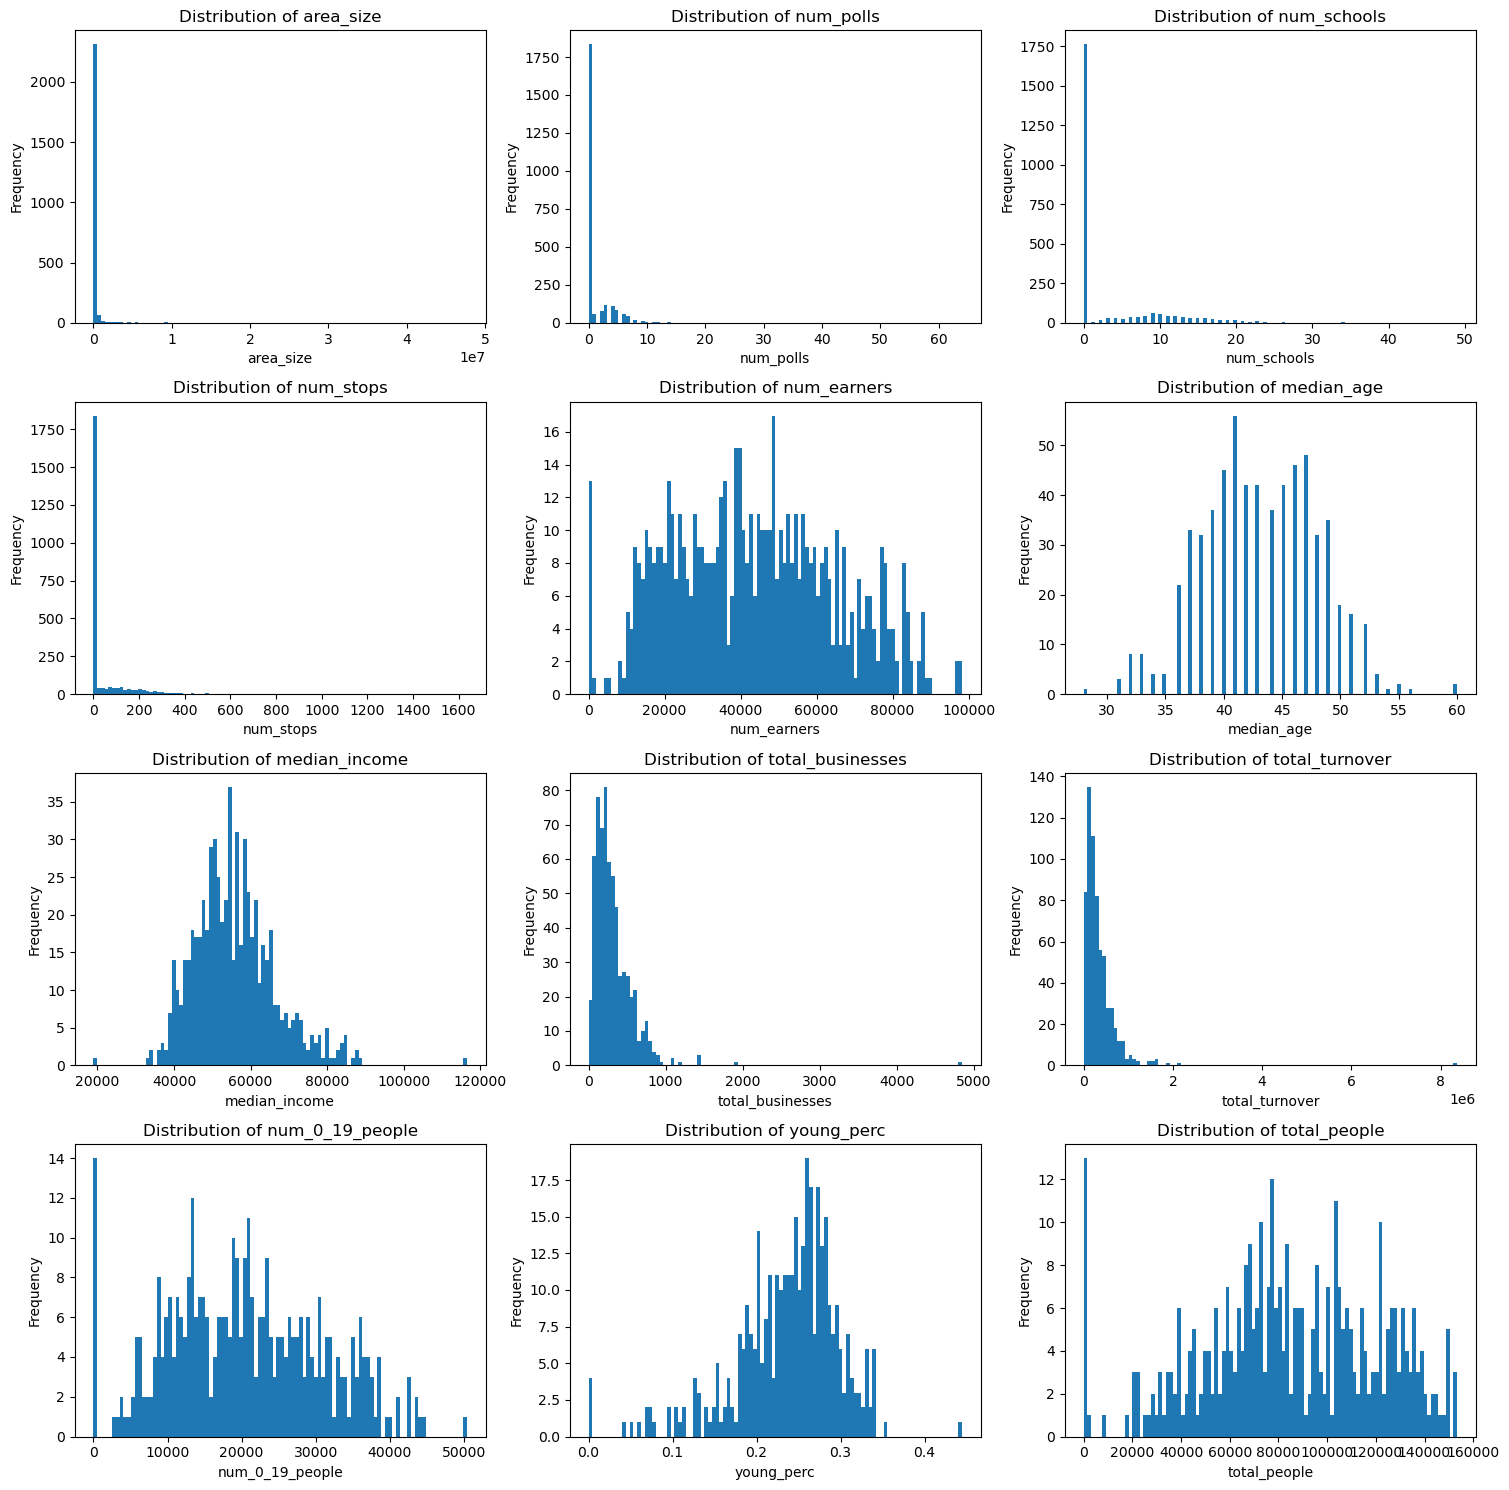

In [ ]:
num_rows = 4
num_cols = 3

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 15))
axs = axs.flatten()

columns_to_plot = [
    'area_size', 'num_polls', 'num_schools', 'num_stops',
    'num_earners', 'median_age', 'median_income', 'total_businesses',
    'total_turnover', 'num_0_19_people', 'young_perc', 'total_people'
]

for i, column in enumerate(columns_to_plot):
    axs[i].hist(df_combined[column], bins=100)
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

Observations:

* Area Size, Number of Polls, Number of Schools, Number of Stops: These distributions are heavily skewed to the right and have a long tail.


* Number of Earners, Median Age: they appear to follow a normal or at least even distributions in both sides and without any big outlier/tail.


* Median Income: Even distribution with long tails on both sides

* Total Businesses, Total Turnover: Right skewness, long tails.

* Number of People (0-19 years old), Young Percentage, Total People: These distributions seem correct (the study of demographics shows that the age distributions always changes over time), although there seems to be an excessive number of 0 year old babies, probably suggesting some mistake in the data.

### 2.2 Create Z-scores

In [ ]:
conn.execute(
	'''
	drop table if exists combined_z_score;
    create table combined_z_score as

    with stats as (
    select avg(num_earners/area_size) as earners_avg
    ,stddev(num_earners/area_size) as earners_stdev
    ,avg(median_age) as age_avg
    ,stddev(median_age) as age_stdev
    ,avg(median_income) as income_avg
    ,stddev(median_income) as income_stdev
    ,avg(total_businesses/total_people * 1000) as num_business_avg
    ,stddev(total_businesses/total_people * 1000) as num_business_stdev
    ,avg(total_turnover/area_size) as turnover_avg
    ,stddev(total_turnover/area_size) as turnover_stdev
    ,avg(num_0_19_people/area_size) as young_num_avg
    ,stddev(num_0_19_people/area_size) as young_num_stdev
    ,avg(Young_perc) as young_perc_avg
    ,stddev(Young_perc) as young_perc_stdev
    ,avg(num_polls/area_size) as polls_avg
    ,stddev(num_polls/area_size) as polls_stdev
    ,avg(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_avg
    ,stddev(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_stdev
    ,avg(num_stops/area_size) as stops_avg
    ,stddev(num_stops/area_size) as stops_stdev
    from combined
    where total_people >= 100
    and "GCC_NAME21" = 'Greater Sydney'
    )
    select "SA2_CODE21","SA2_NAME21","SA3_NAME21","SA4_NAME21","STE_NAME21"
    , (num_earners/total_people * 1000 - earners_avg)/earners_stdev as earners_zscore
    , (median_age - age_avg)/age_stdev as age_zscore
    , (median_income - income_avg)/income_stdev as income_zscore
    , (total_businesses/area_size - num_business_avg)/num_business_stdev as business_zscore
    , (total_turnover/area_size - turnover_avg)/turnover_stdev as turnover_zscore
    , (num_0_19_people/area_size - young_num_avg)/young_num_stdev as yound_population_zscore
    , (young_perc - young_perc_avg)/young_perc_stdev as young_perc_zscore
    , (num_polls/area_size - polls_avg)/polls_stdev as polls_zscore
    , (case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people * 1000 end - schools_avg)/schools_stdev as schools_zscore
    , (num_stops/area_size - stops_avg)/stops_stdev as stops_zscore
    , geom
    from combined
		join stats s on 1=1
    where total_people >=100
		and "GCC_NAME21" = 'Greater Sydney'
    ''')
df_combined_z_score = query(conn, "select * from combined_z_score")
df_combined_z_score.head()

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,geom
0,102011028,Avoca Beach - Copacabana,Gosford,Central Coast,New South Wales,4.306995,1.257331,-0.428353,-0.091271,-0.395554,-0.813326,0.719711,-0.350991,-0.085393,-0.422676,0106000020E6100000010000000103000000010000005E...
1,102011029,Box Head - MacMasters Beach,Gosford,Central Coast,New South Wales,4.051303,1.699736,-0.735436,-0.093496,-0.477304,-1.399971,-0.295490,-0.482361,-0.085385,-1.314594,0106000020E61000000100000001030000000100000010...
2,102011030,Calga - Kulnura,Gosford,Central Coast,New South Wales,4.254544,1.699736,-1.005430,-0.094051,-0.496955,-1.575954,-0.665587,-0.510495,-0.033497,-1.757837,0106000020E61000000200000001030000000100000085...
3,102011031,Erina - Green Point,Gosford,Central Coast,New South Wales,3.549712,1.478533,-0.737589,-0.092574,-0.390362,-1.358381,-0.419027,-0.421358,-0.080091,-1.195543,0106000020E61000000100000001030000000100000041...
4,102011032,Gosford - Springfield,Gosford,Central Coast,New South Wales,3.747963,-0.069885,-0.496170,-0.089774,-0.206451,-0.978978,-0.629935,-0.296270,-0.084581,-0.335446,0106000020E6100000010000000103000000010000007E...


In [ ]:
df_combined_z_score = query(conn, "select * from combined_z_score")

In [ ]:
df_combined_z_score.dtypes

SA2_CODE21                  object
SA2_NAME21                  object
SA3_NAME21                  object
SA4_NAME21                  object
STE_NAME21                  object
earners_zscore             float64
age_zscore                 float64
income_zscore              float64
business_zscore            float64
turnover_zscore            float64
yound_population_zscore    float64
young_perc_zscore          float64
polls_zscore               float64
schools_zscore             float64
stops_zscore               float64
geom                        object
dtype: object

In [ ]:
df_combined_z_score.describe()

,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore
count,364.000000,3.640000e+02,3.640000e+02,364.000000,3.640000e+02,3.640000e+02,3.640000e+02,3.640000e+02,3.640000e+02,3.640000e+02
mean,3.960675,-9.943206e-17,4.880101e-17,-0.084777,1.984066e-16,7.969815e-16,1.631784e-16,-1.471656e-16,1.395404e-17,1.862674e-15
std,1.208527,1.000000e+00,1.000000e+00,0.015151,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,0.077658,-2.945520e+00,-2.306274e+00,-0.094081,-5.006217e-01,-1.578734e+00,-3.442790e+00,-5.153240e-01,-8.942470e-02,-1.772049e+00
25%,3.546988,-7.334935e-01,-6.518393e-01,-0.091878,-3.997002e-01,-7.914129e-01,-5.624724e-01,-3.667907e-01,-8.623434e-02,-7.550099e-01
50%,3.991492,-6.988546e-02,-9.171704e-02,-0.088708,-2.456909e-01,2.077677e-02,1.354673e-01,-2.051914e-01,-8.467777e-02,2.268961e-02
75%,4.351104,8.149252e-01,5.529557e-01,-0.084205,5.442048e-03,6.484978e-01,6.283220e-01,7.404277e-02,-8.168106e-02,7.757876e-01
max,23.037903,2.363344e+00,2.816173e+00,0.060236,1.152073e+01,3.795097e+00,3.564165e+00,1.262914e+01,1.704563e+01,3.078254e+00


### 2.3 Apply sigmoid function and compute score

In [ ]:
# import math

# def sigmoid(x):
#   return 1 / (1 + math.exp(-x))
import numpy as np

def sigmoid(x):  
    return np.exp(-np.logaddexp(0, -x))

In [ ]:
df_combined_z_score['sigmoid_result'] =sigmoid(            
                                      df_combined_z_score['business_zscore']                              
                                    + df_combined_z_score['polls_zscore']               
                                    + df_combined_z_score['schools_zscore']             
                                    + df_combined_z_score['stops_zscore'] )

In [ ]:
df_combined_z_score[['geom','sigmoid_result']].describe()

,sigmoid_result
count,364.000000
mean,0.457322
std,0.255066
min,0.081434
25%,0.226865
50%,0.451595
75%,0.659219
max,1.000000


In [ ]:
df_combined_z_score.to_sql('task_2_result', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from task_2_result")

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,geom,sigmoid_result
0,102011028,Avoca Beach - Copacabana,Gosford,Central Coast,New South Wales,4.306995,1.257331,-0.428353,-0.091271,-0.395554,-0.813326,0.719711,-0.350991,-0.085393,-0.422676,0106000020E6100000010000000103000000010000005E...,0.278818
1,102011029,Box Head - MacMasters Beach,Gosford,Central Coast,New South Wales,4.051303,1.699736,-0.735436,-0.093496,-0.477304,-1.399971,-0.295490,-0.482361,-0.085385,-1.314594,0106000020E61000000100000001030000000100000010...,0.121763
2,102011030,Calga - Kulnura,Gosford,Central Coast,New South Wales,4.254544,1.699736,-1.005430,-0.094051,-0.496955,-1.575954,-0.665587,-0.510495,-0.033497,-1.757837,0106000020E61000000200000001030000000100000085...,0.083487
3,102011031,Erina - Green Point,Gosford,Central Coast,New South Wales,3.549712,1.478533,-0.737589,-0.092574,-0.390362,-1.358381,-0.419027,-0.421358,-0.080091,-1.195543,0106000020E61000000100000001030000000100000041...,0.143126
4,102011032,Gosford - Springfield,Gosford,Central Coast,New South Wales,3.747963,-0.069885,-0.496170,-0.089774,-0.206451,-0.978978,-0.629935,-0.296270,-0.084581,-0.335446,0106000020E6100000010000000103000000010000007E...,0.308728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,128021537,Royal National Park,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,1.605199,-0.954696,-2.198139,-0.094080,-0.500622,-1.578535,3.564165,-0.515324,1.729362,-1.759049,0106000020E61000000100000001030000000100000046...,0.345452
360,128021538,Sutherland - Kirrawee,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,4.001902,-0.069885,0.538008,-0.087230,-0.108918,-0.067166,-0.405287,-0.108701,-0.084282,-0.062877,0106000020E61000000100000001030000000100000089...,0.415059
361,128021607,Engadine,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,3.955978,0.372520,0.416173,-0.091399,-0.370255,-0.259565,0.943743,-0.104544,-0.087268,-0.094757,0106000020E6100000010000000103000000010000008E...,0.406617
362,128021608,Loftus - Yarrawarrah,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,4.060967,0.814925,0.356674,-0.092006,-0.447874,-0.334022,0.723452,-0.241915,-0.082153,0.774499,0106000020E610000001000000010300000001000000A1...,0.588659


In [ ]:
# save output to csv
df_combined_z_score.to_csv('Task_2_results.csv')

In [ ]:
# push to SQL
task2 = gpd.read_postgis('''select sigmoid_result,geom from task_2_result''', conn, crs=4326)
task2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sigmoid_result  364 non-null    float64 
 1   geom            364 non-null    geometry
dtypes: float64(1), geometry(1)
memory usage: 5.8 KB


### 2.4 Visualization 

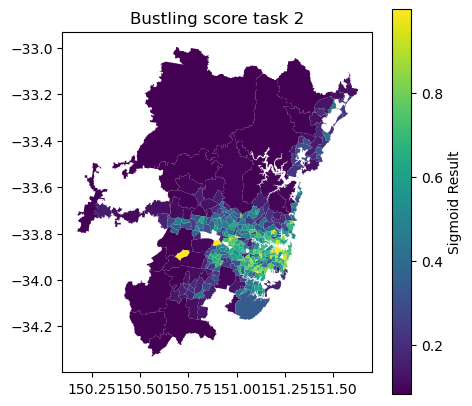

In [ ]:
ax = task2.plot(column='sigmoid_result', figsize=(5, 5), cmap='viridis', legend=False)
plt.colorbar(ax.collections[0], ax=ax, orientation='vertical', label='Sigmoid Result')
plt.title("Bustling score task 2")
plt.show()

In [ ]:
print("Greater sydney has", len(df_sa2[df_sa2['GCC_NAME21'] == 'Greater Sydney']), " SA2 regions")
print("But our bustling score makes predictions for only", len(task2), " SA2 regions")

Greater sydney has 373  SA2 regions
But our bustling score makes predictions for only 364  SA2 regions


In [1]:
df_combined_greater_sydney = df_combined[df_combined['GCC_NAME21'] == 'Greater Sydney']
len(df_combined_greater_sydney[df_combined_greater_sydney["total_people"] < 100])

NameError: name 'df_combined' is not defined

As we can see this difference is due to the fact that we filtered out regions with population of less than 100, which led to exclude 9 regions.

## Task 3